In [4]:
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

RAW_DIR = Path("datasets/BSD400")
OUT_DIR = Path("datasets/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PATCH_SIZE = 8
STRIDE = 4
MAX_PATCHES_PER_IMAGE = 512
SEED = 0

OUT_PATH = OUT_DIR / f"bsd400_patches_{PATCH_SIZE}x{PATCH_SIZE}.npy"

rng = np.random.default_rng(SEED)

In [5]:
image_paths = sorted([
    p for p in RAW_DIR.glob("*")
    if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
])

len(image_paths), image_paths[:5]

(400,
 [PosixPath('datasets/BSD400/test_001.png'),
  PosixPath('datasets/BSD400/test_002.png'),
  PosixPath('datasets/BSD400/test_003.png'),
  PosixPath('datasets/BSD400/test_004.png'),
  PosixPath('datasets/BSD400/test_005.png')])

(180, 180) 0.07058824 0.90588236


(np.float64(-0.5), np.float64(179.5), np.float64(179.5), np.float64(-0.5))

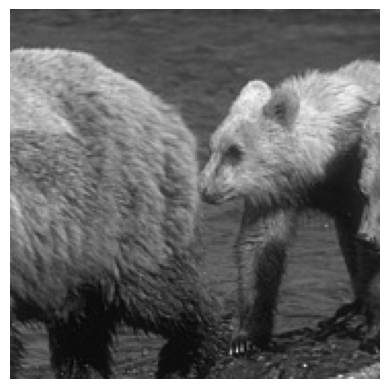

In [6]:
# 이미지 로드 함수
def load_gray_image(path):
    img = Image.open(path).convert("L")
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

img = load_gray_image(image_paths[0])
print(img.shape, img.min(), img.max())

plt.imshow(img, cmap="gray")
plt.axis("off")

In [7]:
# patch 추출 함수
def extract_patches(img, patch_size=8, stride=4):
    h, w = img.shape
    patches = []

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img[y:y + patch_size, x:x + patch_size]
            patches.append(patch.reshape(-1))

    return np.stack(patches, axis=0).astype(np.float32)

In [8]:
# BSD400 전체를 학습 데이터로 변환

all_patches = []

for path in image_paths:
    img = load_gray_image(path)
    patches = extract_patches(img, PATCH_SIZE, STRIDE)

    if len(patches) > MAX_PATCHES_PER_IMAGE:
        idx = rng.choice(len(patches), size=MAX_PATCHES_PER_IMAGE, replace=False)
        patches = patches[idx]

    all_patches.append(patches)

data = np.concatenate(all_patches, axis=0)

print(data.shape)  # [N, PATCH_SIZE * PATCH_SIZE]
print(data.min(), data.max(), data.dtype)

(204800, 64)
0.0 1.0 float32


In [9]:
np.save(OUT_PATH, data)
print(f"saved: {OUT_PATH}")
print(f"input_dim: {data.shape[1]}")

saved: datasets/processed/bsd400_patches_8x8.npy
input_dim: 64


In [10]:
from data import make_ardae_dataloader

loader = make_ardae_dataloader(
    data,
    input_dim=data.shape[1],
    batch_size=128,
    normalize=None,
)

batch = next(iter(loader))
batch.shape, batch.min(), batch.max()

(torch.Size([128, 64]), tensor(0.0118), tensor(1.))